# 02 — Preprocessing for Topic Modeling

This notebook prepares the BIS central bank speeches corpus for the NLP models used in the project.

The objective is to build a clean modeling dataset that can be used in the next notebooks:

- **NMF topic modeling** with TF-IDF features;
- **LDA topic modeling** with count-based features;
- **BERTopic**, using transformer-based document embeddings;
- **Hawkish/dovish tone analysis**, using normalized dictionary scores.

The preprocessing decisions are based on the exploratory data analysis from Notebook 01. In particular, the EDA showed that the corpus contains some missing or empty texts, a small number of exact duplicates, very short documents, and generic words that should not dominate the topic models.

## 1. Imports and global settings

I start by importing the libraries used in this notebook. I keep the preprocessing code in the notebook rather than in external `.py` files to make the workflow easier to read and reproduce.

In [1]:
import re
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset
from tqdm.auto import tqdm
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 180)

## 2. Load the raw dataset

The dataset is provided as a single Hugging Face split named `train`. This does not mean that I am using it as a supervised training set. It simply means that the dataset authors stored all observations in one split. Since the project focuses on unsupervised topic modeling and descriptive tone analysis, the absence of predefined validation and test splits is not an issue.

In [2]:
dataset = load_dataset("samchain/bis_central_bank_speeches")

print(dataset)
print("Available splits:", list(dataset.keys()))

df = dataset["train"].to_pandas()

print("Raw shape:", df.shape)
df.head()

DatasetDict({
    train: Dataset({
        features: ['description', 'text', 'bank', 'Year', 'Month'],
        num_rows: 19376
    })
})
Available splits: ['train']
Raw shape: (19376, 5)


,description,text,bank,Year,Month
0,"Lecture delivered in honour of Professor Xenophon Zolotas, Honorary Governor of the Bank of Greece, by the President of the Deutsche Bundesbank, Prof. Hans Tietmeyer, in Athens...","Mr. Tietmeyer considers European monetary integration and its implications for the international monetary system Lecture delivered in honour of Professor Xenophon Zolotas, Hono...",bank of greece,1997,10
1,"Speech given by Mr Nicholas C Garganas, Deputy Governor of the Bank of Greece, at the 'Athens Summit 1999' on 18 September 1999.","Mr Garganas gives a speech on integrating Greece into the euro area and the challenges ahead Speech given by Mr Nicholas C Garganas, Deputy Governor of the Bank of Greece, at t...",bank of greece,1999,9
2,"Address by Mr Nicholas C Garganas, Deputy Governor of the Bank of Greece, at the Euromoney International Bond Congress, held in London on 15 February 2000.",None,bank of greece,2000,3
3,"Speech by Mr Lucas Papademos, Governor of the Bank of Greece, at the Euro Information Conference, Athens, 17 October 2001.","Lucas Papademos: The completion of the changeover to the euro Speech by Mr Lucas Papademos, Governor of the Bank of Greece, at the Euro Information Conference, Athens, 17 Octob...",bank of greece,2001,10
4,"Address by Mr Nicholas C Garganas, Deputy Governor of the Bank of Greece, to the Hellenic American Bankers Association, New York, 23 April 2002.","Nicholas Garganas: The Greek economy within the euro area Address by Mr Nicholas C Garganas, Deputy Governor of the Bank of Greece, to the Hellenic American Bankers Association...",bank of greece,2002,5


## 3. Rename columns

The raw dataset contains five columns. I rename them to make the rest of the notebook clearer:

- `text` becomes `raw_text`;
- `bank` becomes `central_bank`;
- `Year` becomes `year`;
- `Month` becomes `month`.

The `raw_text` column is the main text field used for NLP modeling.

In [3]:
df = df.rename(columns={
    "text": "raw_text",
    "bank": "central_bank",
    "Year": "year",
    "Month": "month"
})

df.head()

,description,raw_text,central_bank,year,month
0,"Lecture delivered in honour of Professor Xenophon Zolotas, Honorary Governor of the Bank of Greece, by the President of the Deutsche Bundesbank, Prof. Hans Tietmeyer, in Athens...","Mr. Tietmeyer considers European monetary integration and its implications for the international monetary system Lecture delivered in honour of Professor Xenophon Zolotas, Hono...",bank of greece,1997,10
1,"Speech given by Mr Nicholas C Garganas, Deputy Governor of the Bank of Greece, at the 'Athens Summit 1999' on 18 September 1999.","Mr Garganas gives a speech on integrating Greece into the euro area and the challenges ahead Speech given by Mr Nicholas C Garganas, Deputy Governor of the Bank of Greece, at t...",bank of greece,1999,9
2,"Address by Mr Nicholas C Garganas, Deputy Governor of the Bank of Greece, at the Euromoney International Bond Congress, held in London on 15 February 2000.",None,bank of greece,2000,3
3,"Speech by Mr Lucas Papademos, Governor of the Bank of Greece, at the Euro Information Conference, Athens, 17 October 2001.","Lucas Papademos: The completion of the changeover to the euro Speech by Mr Lucas Papademos, Governor of the Bank of Greece, at the Euro Information Conference, Athens, 17 Octob...",bank of greece,2001,10
4,"Address by Mr Nicholas C Garganas, Deputy Governor of the Bank of Greece, to the Hellenic American Bankers Association, New York, 23 April 2002.","Nicholas Garganas: The Greek economy within the euro area Address by Mr Nicholas C Garganas, Deputy Governor of the Bank of Greece, to the Hellenic American Bankers Association...",bank of greece,2002,5


## 4. Recreate useful metadata

The EDA introduced broad macro-financial periods to help interpret the temporal evolution of topics. I recreate this variable here so that the final modeling dataset contains all the metadata needed for the following notebooks.

These periods are not official labels from the dataset. They are a macroeconomic interpretation grid used only for analysis.

In [4]:
def assign_macro_period(year):
    if pd.isna(year):
        return "Unknown"
    year = int(year)
    if year <= 2006:
        return "Pre-GFC"
    elif 2007 <= year <= 2009:
        return "Global Financial Crisis"
    elif 2010 <= year <= 2014:
        return "Euro crisis / post-GFC"
    elif 2015 <= year <= 2019:
        return "Low rates / QE"
    elif 2020 <= year <= 2021:
        return "Covid"
    elif year >= 2022:
        return "Inflation tightening"
    else:
        return "Unknown"

df["macro_period"] = df["year"].apply(assign_macro_period)

df[["year", "month", "macro_period", "central_bank"]].head()

,year,month,macro_period,central_bank
0,1997,10,Pre-GFC,bank of greece
1,1999,9,Pre-GFC,bank of greece
2,2000,3,Pre-GFC,bank of greece
3,2001,10,Pre-GFC,bank of greece
4,2002,5,Pre-GFC,bank of greece


## 5. Identify missing and empty texts

In the EDA, I found that some observations have missing `raw_text`. It is also possible to have non-missing strings that are actually empty or contain only spaces. I therefore create a stripped text column and identify usable text entries.

In [5]:
df["raw_text_stripped"] = df["raw_text"].fillna("").astype(str).str.strip()

df["has_non_empty_text"] = df["raw_text_stripped"].str.len() > 0

text_quality_summary = pd.DataFrame({
    "count": [
        len(df),
        df["raw_text"].isna().sum(),
        (df["raw_text_stripped"] == "").sum(),
        df["has_non_empty_text"].sum()
    ]
}, index=[
    "Total observations",
    "Missing raw_text values",
    "Empty or missing text after stripping",
    "Non-empty texts"
])

text_quality_summary

,count
Total observations,19376
Missing raw_text values,165
Empty or missing text after stripping,191
Non-empty texts,19185


The rows with missing or empty text cannot be used for topic modeling. I remove them in the next step.

In [6]:
df_text = df[df["has_non_empty_text"]].copy()

print("Shape before removing missing/empty texts:", df.shape)
print("Shape after removing missing/empty texts:", df_text.shape)
print(f"Share kept: {len(df_text) / len(df):.2%}")

Shape before removing missing/empty texts: (19376, 8)
Shape after removing missing/empty texts: (19185, 8)
Share kept: 99.01%


## 6. Compute raw text length

Before filtering short documents, I compute the number of words and characters in the raw text. This allows me to check how much of the corpus would be removed under different minimum-length thresholds.

In [7]:
def count_words(text):
    if pd.isna(text):
        return 0
    return len(str(text).split())

def count_characters(text):
    if pd.isna(text):
        return 0
    return len(str(text))

df_text["n_words_raw"] = df_text["raw_text_stripped"].apply(count_words)
df_text["n_characters_raw"] = df_text["raw_text_stripped"].apply(count_characters)

df_text[["n_words_raw", "n_characters_raw"]].describe()

,n_words_raw,n_characters_raw
count,19185.000000,19185.000000
mean,2745.424186,17491.949857
std,1773.743049,11325.462588
min,44.000000,297.000000
25%,1489.000000,9599.000000
50%,2408.000000,15336.000000
75%,3604.000000,22897.000000
max,48814.000000,340677.000000


## 7. Remove exact duplicate speeches

Exact duplicate speeches can bias topic modeling because repeated documents give excessive weight to the same vocabulary. I therefore remove exact duplicates based on the stripped raw text.

In [8]:
n_duplicates_before = df_text.duplicated(subset=["raw_text_stripped"]).sum()

df_text = df_text.drop_duplicates(subset=["raw_text_stripped"]).copy()

print("Exact duplicates removed:", n_duplicates_before)
print("Shape after duplicate removal:", df_text.shape)

Exact duplicates removed: 15
Shape after duplicate removal: (19170, 10)


## 8. Inspect short documents

Short documents may not contain enough context for reliable topic assignment. I inspect how many speeches would be removed under different word-count thresholds.

In [9]:
thresholds = [50, 100, 200, 300, 500]

short_doc_table = []
for threshold in thresholds:
    n_below = (df_text["n_words_raw"] < threshold).sum()
    short_doc_table.append({
        "threshold_words": threshold,
        "n_documents_below_threshold": n_below,
        "share_of_current_corpus": n_below / len(df_text)
    })

short_doc_table = pd.DataFrame(short_doc_table)
short_doc_table

,threshold_words,n_documents_below_threshold,share_of_current_corpus
0,50,1,0.000052
1,100,4,0.000209
2,200,19,0.000991
3,300,65,0.003391
4,500,288,0.015023


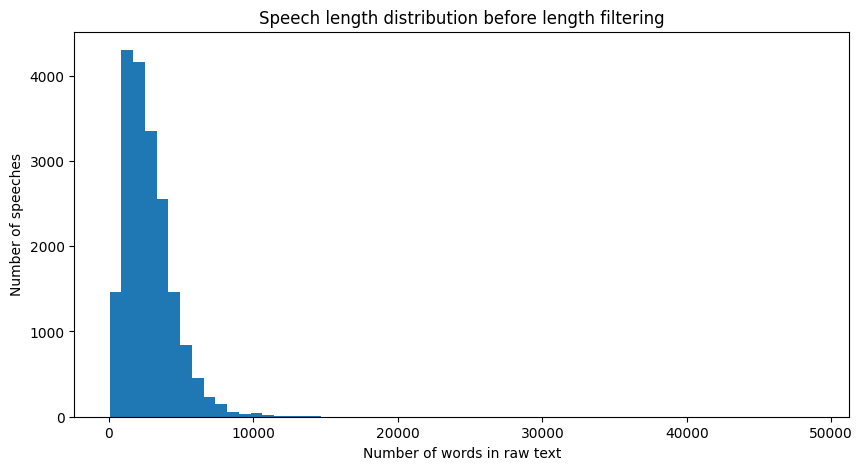

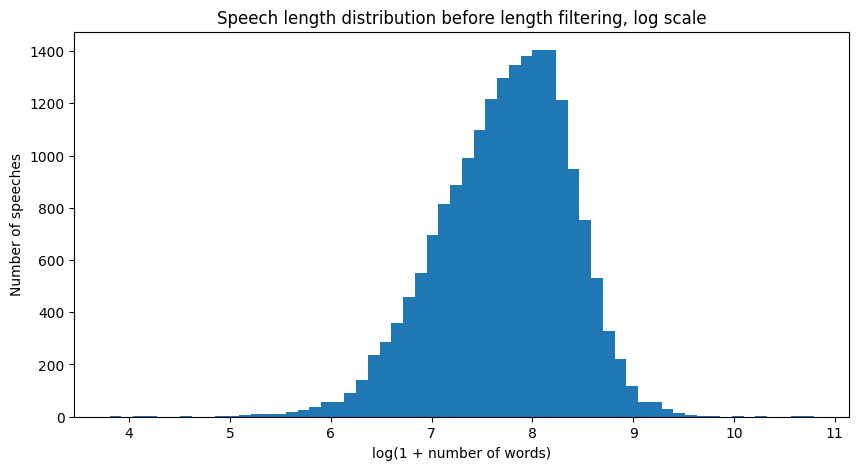

In [10]:
plt.figure(figsize=(10, 5))
plt.hist((df_text["n_words_raw"]), bins=60)
plt.xlabel("Number of words in raw text")
plt.ylabel("Number of speeches")
plt.title("Speech length distribution before length filtering")
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(np.log1p(df_text["n_words_raw"]), bins=60)
plt.xlabel("log(1 + number of words)")
plt.ylabel("Number of speeches")
plt.title("Speech length distribution before length filtering, log scale")
plt.show()

I choose a minimum threshold of **200 raw words**. This removes very short texts while keeping almost all of the corpus. The threshold is conservative because central bank speeches are usually long documents; a document with fewer than 200 words is unlikely to provide enough context for topic modeling.

In [11]:
MIN_RAW_WORDS = 200

df_text = df_text[df_text["n_words_raw"] >= MIN_RAW_WORDS].copy()

print("Shape after filtering short documents:", df_text.shape)
print(f"Share of original dataset kept: {len(df_text) / len(df):.2%}")

Shape after filtering short documents: (19151, 10)
Share of original dataset kept: 98.84%


## 9. Define stopwords

For classical topic modeling methods such as NMF and LDA, I need a cleaned text representation. I remove standard English stopwords and add corpus-specific stopwords.

The corpus-specific stopwords include words that are frequent in central bank speeches but do not help distinguish topics, such as `central`, `bank`, `speech`, `year`, and `time`.

I keep monetary and financial terms such as `inflation`, `policy`, `rate`, `financial`, and `market`, because these words are central to the research question.

In [12]:
standard_stopwords = set(ENGLISH_STOP_WORDS)


domain_stopwords = {
    # Very frequent corpus descriptors
    "central", "bank", "banks", "speech", "speeches",
    "speaker", "governor", "deputy", "mr", "mrs", "ms", "dr",

    # Generic time and discourse words
    "year", "years", "month", "months", "today", "tomorrow",
    "time", "times", "period", "periods", "recent", "currently",

    # Generic words often frequent in formal speeches
    "also", "would", "could", "should", "may", "might", "must",
    "many", "much", "well", "like", "make", "made", "way", "ways",
    "new", "old", "good", "important", "particular", "example",
    "first", "second", "third", "finally", "however", "therefore",
    "indeed", "although", "among", "across", "within", "without"
}

stopwords = standard_stopwords.union(domain_stopwords)

print("Number of stopwords:", len(stopwords))
print(sorted(list(domain_stopwords))[:30])

Number of stopwords: 354
['across', 'also', 'although', 'among', 'bank', 'banks', 'central', 'could', 'currently', 'deputy', 'dr', 'example', 'finally', 'first', 'good', 'governor', 'however', 'important', 'indeed', 'like', 'made', 'make', 'many', 'may', 'might', 'month', 'months', 'mr', 'mrs', 'ms']


## 10. Clean text for classical topic models

I create a `clean_text` column for TF-IDF, NMF, and LDA.

The cleaning steps are:

1. lowercase the text;
2. remove URLs and email addresses;
3. keep only alphabetic characters;
4. tokenize by whitespace;
5. remove short tokens;
6. remove stopwords;
7. join tokens back into a cleaned string.

This representation is appropriate for bag-of-words models, but it is more aggressive than what will be used for BERTopic.

In [13]:
def clean_text_for_classical_models(text, stopwords):
    if pd.isna(text):
        return ""

    text = str(text).lower()

    # Remove URLs and email addresses
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"\S+@\S+", " ", text)

    # Keep alphabetic characters only
    text = re.sub(r"[^a-z\s]", " ", text)

    # Normalize whitespace
    text = re.sub(r"\s+", " ", text).strip()

    tokens = text.split() #un token = un mot.

    tokens = [
        tok for tok in tokens
        if len(tok) > 2
        and tok not in stopwords
    ]

    return " ".join(tokens)

tqdm.pandas()

df_text["clean_text"] = df_text["raw_text_stripped"].progress_apply(
    lambda x: clean_text_for_classical_models(x, stopwords)
)

df_text["n_words_clean"] = df_text["clean_text"].apply(lambda x: len(x.split()))

df_text[["raw_text_stripped", "clean_text", "n_words_raw", "n_words_clean"]].head()

  0%|          | 0/19151 [00:00<?, ?it/s]

,raw_text_stripped,clean_text,n_words_raw,n_words_clean
0,"Mr. Tietmeyer considers European monetary integration and its implications for the international monetary system Lecture delivered in honour of Professor Xenophon Zolotas, Hono...",tietmeyer considers european monetary integration implications international monetary lecture delivered honour professor xenophon zolotas honorary greece president deutsche bun...,5070,2295
1,"Mr Garganas gives a speech on integrating Greece into the euro area and the challenges ahead Speech given by Mr Nicholas C Garganas, Deputy Governor of the Bank of Greece, at t...",garganas gives integrating greece euro area challenges ahead given nicholas garganas greece athens summit september adoption euro common currency group european union member st...,2307,1151
3,"Lucas Papademos: The completion of the changeover to the euro Speech by Mr Lucas Papademos, Governor of the Bank of Greece, at the Euro Information Conference, Athens, 17 Octob...",lucas papademos completion changeover euro lucas papademos greece euro information conference athens october welcome session euro information conference presence attests import...,2975,1306
4,"Nicholas Garganas: The Greek economy within the euro area Address by Mr Nicholas C Garganas, Deputy Governor of the Bank of Greece, to the Hellenic American Bankers Association...",nicholas garganas greek economy euro area address nicholas garganas greece hellenic american bankers association york april gives great pleasure able address transformation gre...,2129,1061
5,"Nicholas C Garganas: The European financial marketplace Speech by Mr Nicholas C Garganas, Governor of the Bank of Greece, at The Economist Conference: Private Banking and Asset...",nicholas garganas european financial marketplace nicholas garganas greece economist conference private banking asset management athens october ladies gentlemen let start thanki...,2001,1036


## 11. Create a lighter text version for BERTopic

Transformer-based models can benefit from more natural language context. Therefore, for BERTopic I keep a less aggressively cleaned text column. I remove URLs and extra whitespace, but I do not remove stopwords or punctuation as aggressively as for TF-IDF/NMF/LDA.

In [14]:
def clean_text_for_bertopic(text):
    if pd.isna(text):
        return ""

    text = str(text)
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"\S+@\S+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text

df_text["bertopic_text"] = df_text["raw_text_stripped"].apply(clean_text_for_bertopic)

df_text[["bertopic_text"]].head()

,bertopic_text
0,"Mr. Tietmeyer considers European monetary integration and its implications for the international monetary system Lecture delivered in honour of Professor Xenophon Zolotas, Hono..."
1,"Mr Garganas gives a speech on integrating Greece into the euro area and the challenges ahead Speech given by Mr Nicholas C Garganas, Deputy Governor of the Bank of Greece, at t..."
3,"Lucas Papademos: The completion of the changeover to the euro Speech by Mr Lucas Papademos, Governor of the Bank of Greece, at the Euro Information Conference, Athens, 17 Octob..."
4,"Nicholas Garganas: The Greek economy within the euro area Address by Mr Nicholas C Garganas, Deputy Governor of the Bank of Greece, to the Hellenic American Bankers Association..."
5,"Nicholas C Garganas: The European financial marketplace Speech by Mr Nicholas C Garganas, Governor of the Bank of Greece, at The Economist Conference: Private Banking and Asset..."


## 12. Filter documents after cleaning

Some texts may become too short after cleaning. I therefore apply a second filter based on the number of cleaned words. This ensures that the documents used by the classical topic models still contain enough vocabulary after stopword removal.

In [15]:
MIN_CLEAN_WORDS = 100

before_clean_filter = len(df_text)

df_model = df_text[df_text["n_words_clean"] >= MIN_CLEAN_WORDS].copy()

after_clean_filter = len(df_model)

print("Documents before cleaned-length filtering:", before_clean_filter)
print("Documents after cleaned-length filtering:", after_clean_filter)
print("Documents removed:", before_clean_filter - after_clean_filter)
print(f"Share of original dataset kept: {len(df_model) / len(df):.2%}")

Documents before cleaned-length filtering: 19151
Documents after cleaned-length filtering: 18964
Documents removed: 187
Share of original dataset kept: 97.87%


## 13. Final corpus diagnostics

I now inspect the final modeling corpus. The goal is to verify that the dataset is still large, temporally rich, and suitable for the next topic modeling notebooks.

In [16]:
final_summary = {
    "raw_observations": len(df),
    "after_missing_and_empty_text_removal": int(text_quality_summary.loc["Non-empty texts", "count"]),
    "after_duplicate_and_raw_length_filtering": len(df_text),
    "final_modeling_corpus": len(df_model),
    "share_of_raw_dataset_kept": len(df_model) / len(df),
    "min_year": int(df_model["year"].min()),
    "max_year": int(df_model["year"].max()),
    "n_central_banks": int(df_model["central_bank"].nunique()),
    "mean_raw_words": float(df_model["n_words_raw"].mean()),
    "median_raw_words": float(df_model["n_words_raw"].median()),
    "mean_clean_words": float(df_model["n_words_clean"].mean()),
    "median_clean_words": float(df_model["n_words_clean"].median())
}

final_summary_df = pd.DataFrame([final_summary]).T
final_summary_df.columns = ["value"]
final_summary_df

,value
raw_observations,19376.000000
after_missing_and_empty_text_removal,19185.000000
after_duplicate_and_raw_length_filtering,19151.000000
final_modeling_corpus,18964.000000
share_of_raw_dataset_kept,0.978737
min_year,1997.000000
max_year,2025.000000
n_central_banks,118.000000
mean_raw_words,2764.318287
median_raw_words,2429.000000


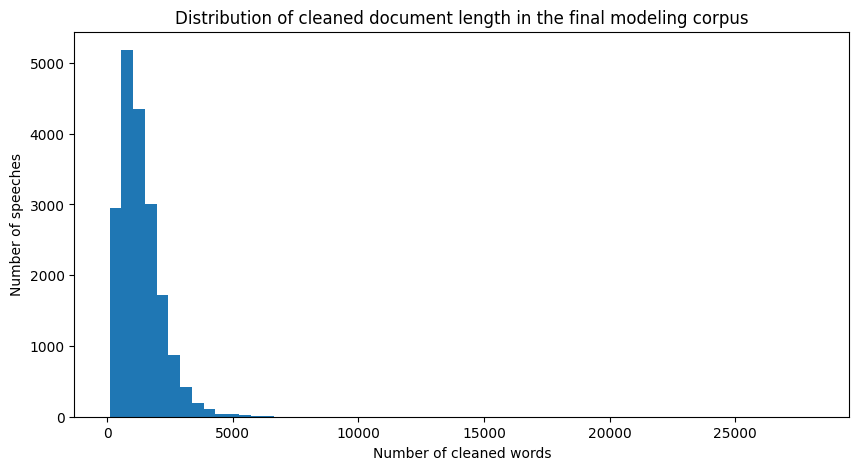

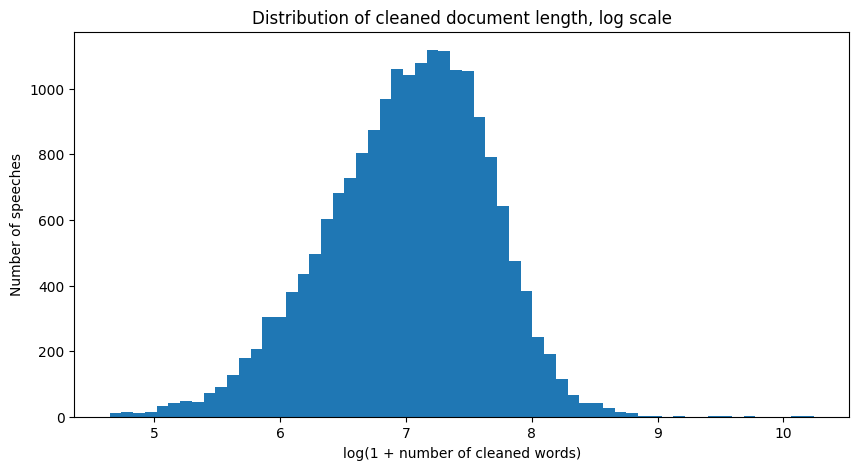

In [17]:
plt.figure(figsize=(10, 5))
plt.hist(df_model["n_words_clean"], bins=60)
plt.xlabel("Number of cleaned words")
plt.ylabel("Number of speeches")
plt.title("Distribution of cleaned document length in the final modeling corpus")
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(np.log1p(df_model["n_words_clean"]), bins=60)
plt.xlabel("log(1 + number of cleaned words)")
plt.ylabel("Number of speeches")
plt.title("Distribution of cleaned document length, log scale")
plt.show()

## 14. Check temporal and institutional coverage after preprocessing

Preprocessing should not strongly distort the temporal or institutional structure of the dataset. I therefore check the number of speeches by year, by macro-financial period, and by central bank after filtering.

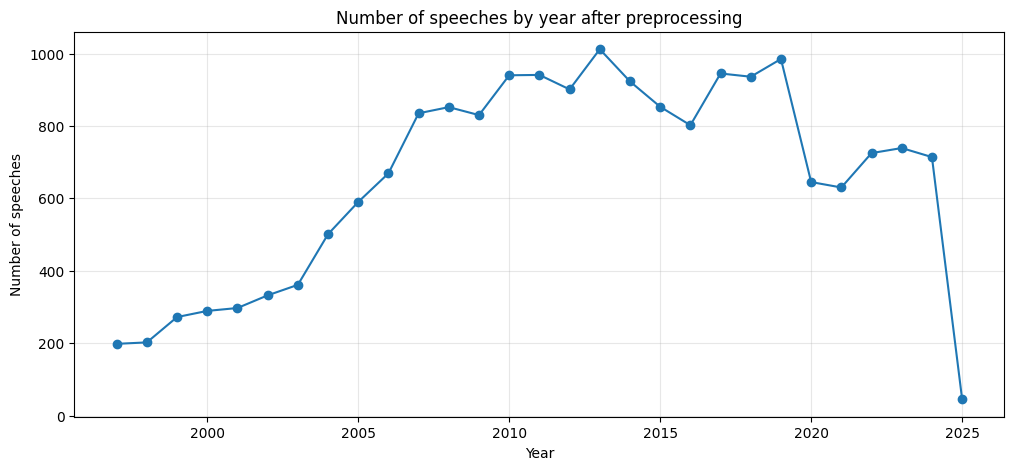

In [18]:
speeches_by_year_clean = (
    df_model.groupby("year")
    .size()
    .reset_index(name="n_speeches")
    .sort_values("year")
)

plt.figure(figsize=(12, 5))
plt.plot(speeches_by_year_clean["year"], speeches_by_year_clean["n_speeches"], marker="o")
plt.xlabel("Year")
plt.ylabel("Number of speeches")
plt.title("Number of speeches by year after preprocessing")
plt.grid(alpha=0.3)
plt.show()

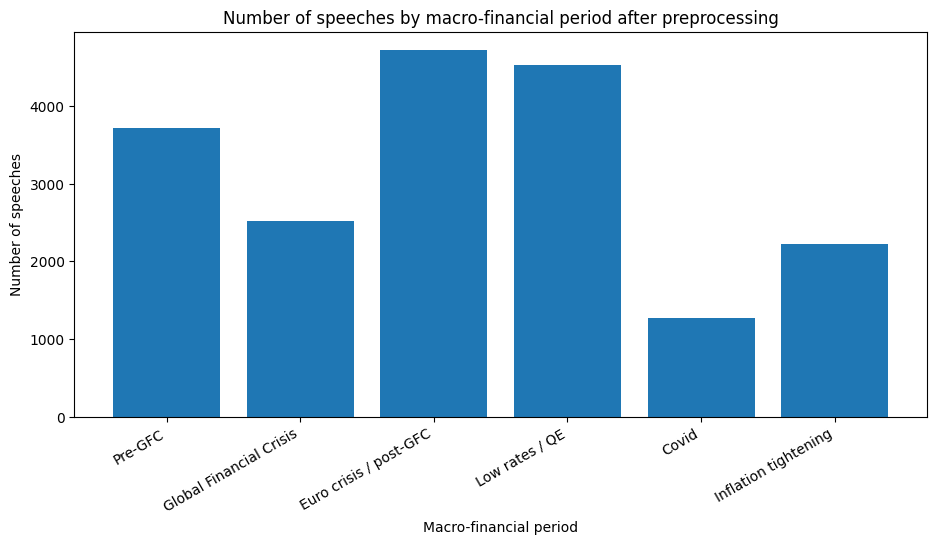

,macro_period,n_speeches
0,Pre-GFC,3711
1,Global Financial Crisis,2517
2,Euro crisis / post-GFC,4717
3,Low rates / QE,4521
4,Covid,1275
5,Inflation tightening,2223


In [19]:
period_order = [
    "Pre-GFC",
    "Global Financial Crisis",
    "Euro crisis / post-GFC",
    "Low rates / QE",
    "Covid",
    "Inflation tightening"
]

period_counts_clean = (
    df_model["macro_period"]
    .value_counts()
    .reindex(period_order)
    .dropna()
    .reset_index()
)

period_counts_clean.columns = ["macro_period", "n_speeches"]

plt.figure(figsize=(11, 5))
plt.bar(period_counts_clean["macro_period"], period_counts_clean["n_speeches"])
plt.xlabel("Macro-financial period")
plt.ylabel("Number of speeches")
plt.title("Number of speeches by macro-financial period after preprocessing")
plt.xticks(rotation=30, ha="right")
plt.show()

period_counts_clean

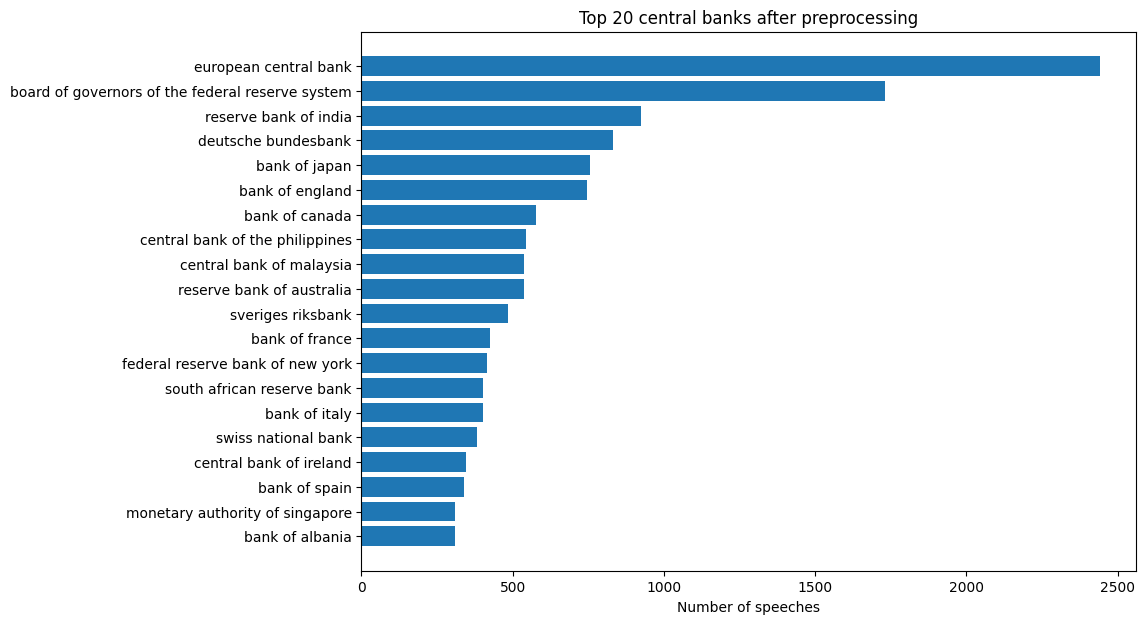

,central_bank,n_speeches
0,european central bank,2440
1,board of governors of the federal reserve system,1732
2,reserve bank of india,924
3,deutsche bundesbank,833
4,bank of japan,757
5,bank of england,747
6,bank of canada,578
7,central bank of the philippines,545
8,central bank of malaysia,537
9,reserve bank of australia,536


In [20]:
top_banks_clean = (
    df_model["central_bank"]
    .value_counts()
    .head(20)
    .reset_index()
)

top_banks_clean.columns = ["central_bank", "n_speeches"]

plt.figure(figsize=(10, 7))
plt.barh(top_banks_clean["central_bank"][::-1], top_banks_clean["n_speeches"][::-1])
plt.xlabel("Number of speeches")
plt.title("Top 20 central banks after preprocessing")
plt.show()

top_banks_clean.head(10)

## 15. Inspect most frequent words after final cleaning

I now check the most frequent words in the final `clean_text` column. This helps verify that the cleaning removed generic terms while preserving monetary and financial vocabulary.

In [21]:
all_clean_tokens = []

for text in tqdm(df_model["clean_text"]):
    all_clean_tokens.extend(text.split())

clean_word_counts = Counter(all_clean_tokens)
top_clean_words = pd.DataFrame(clean_word_counts.most_common(40), columns=["word", "count"])

top_clean_words.head(30)

  0%|          | 0/18964 [00:00<?, ?it/s]

,word,count
0,financial,327801
1,policy,219032
2,monetary,165305
3,inflation,155508
4,market,150001
5,economic,148631
6,growth,136609
7,rate,126677
8,economy,124669
9,risk,105994


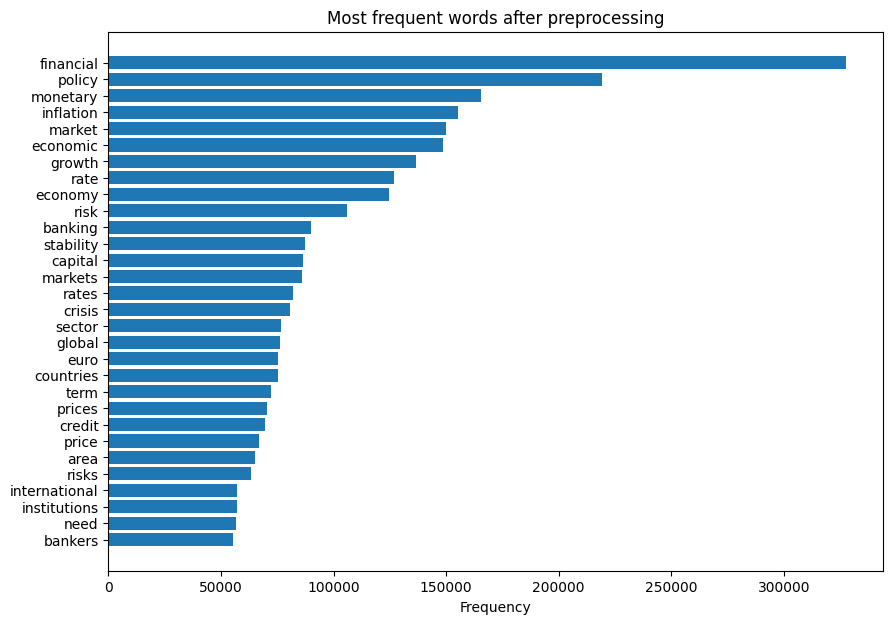

In [22]:
plt.figure(figsize=(10, 7))
plt.barh(top_clean_words["word"].head(30)[::-1], top_clean_words["count"].head(30)[::-1])
plt.xlabel("Frequency")
plt.title("Most frequent words after preprocessing")
plt.show()

The most frequent words after preprocessing should still include meaningful terms such as `financial`, `policy`, `monetary`, `inflation`, `market`, `growth`, `rate`, `risk`, and `stability`. This indicates that the cleaning process preserves the vocabulary needed for monetary-policy topic modeling.

## 16. Keep useful columns for the following notebooks

I keep both versions of the text:

- `clean_text` for TF-IDF, NMF, and LDA;
- `bertopic_text` for BERTopic.

I also keep the key metadata needed for temporal and institutional analysis.

In [23]:
columns_to_keep = [
    "description",
    "raw_text_stripped",
    "clean_text",
    "bertopic_text",
    "central_bank",
    "year",
    "month",
    "macro_period",
    "n_words_raw",
    "n_characters_raw",
    "n_words_clean"
]

df_model = df_model[columns_to_keep].reset_index(drop=True)

df_model.head()

,description,raw_text_stripped,clean_text,bertopic_text,central_bank,year,month,macro_period,n_words_raw,n_characters_raw,n_words_clean
0,"Lecture delivered in honour of Professor Xenophon Zolotas, Honorary Governor of the Bank of Greece, by the President of the Deutsche Bundesbank, Prof. Hans Tietmeyer, in Athens...","Mr. Tietmeyer considers European monetary integration and its implications for the international monetary system Lecture delivered in honour of Professor Xenophon Zolotas, Hono...",tietmeyer considers european monetary integration implications international monetary lecture delivered honour professor xenophon zolotas honorary greece president deutsche bun...,"Mr. Tietmeyer considers European monetary integration and its implications for the international monetary system Lecture delivered in honour of Professor Xenophon Zolotas, Hono...",bank of greece,1997,10,Pre-GFC,5070,31212,2295
1,"Speech given by Mr Nicholas C Garganas, Deputy Governor of the Bank of Greece, at the 'Athens Summit 1999' on 18 September 1999.","Mr Garganas gives a speech on integrating Greece into the euro area and the challenges ahead Speech given by Mr Nicholas C Garganas, Deputy Governor of the Bank of Greece, at t...",garganas gives integrating greece euro area challenges ahead given nicholas garganas greece athens summit september adoption euro common currency group european union member st...,"Mr Garganas gives a speech on integrating Greece into the euro area and the challenges ahead Speech given by Mr Nicholas C Garganas, Deputy Governor of the Bank of Greece, at t...",bank of greece,1999,9,Pre-GFC,2307,14497,1151
2,"Speech by Mr Lucas Papademos, Governor of the Bank of Greece, at the Euro Information Conference, Athens, 17 October 2001.","Lucas Papademos: The completion of the changeover to the euro Speech by Mr Lucas Papademos, Governor of the Bank of Greece, at the Euro Information Conference, Athens, 17 Octob...",lucas papademos completion changeover euro lucas papademos greece euro information conference athens october welcome session euro information conference presence attests import...,"Lucas Papademos: The completion of the changeover to the euro Speech by Mr Lucas Papademos, Governor of the Bank of Greece, at the Euro Information Conference, Athens, 17 Octob...",bank of greece,2001,10,Pre-GFC,2975,18231,1306
3,"Address by Mr Nicholas C Garganas, Deputy Governor of the Bank of Greece, to the Hellenic American Bankers Association, New York, 23 April 2002.","Nicholas Garganas: The Greek economy within the euro area Address by Mr Nicholas C Garganas, Deputy Governor of the Bank of Greece, to the Hellenic American Bankers Association...",nicholas garganas greek economy euro area address nicholas garganas greece hellenic american bankers association york april gives great pleasure able address transformation gre...,"Nicholas Garganas: The Greek economy within the euro area Address by Mr Nicholas C Garganas, Deputy Governor of the Bank of Greece, to the Hellenic American Bankers Association...",bank of greece,2002,5,Pre-GFC,2129,13387,1061
4,"Speech by Mr Nicholas C Garganas, Governor of the Bank of Greece, at The Economist Conference: Private Banking and Asset Management, Athens, 22 October 2002.","Nicholas C Garganas: The European financial marketplace Speech by Mr Nicholas C Garganas, Governor of the Bank of Greece, at The Economist Conference: Private Banking and Asset...",nicholas garganas european financial marketplace nicholas garganas greece economist conference private banking asset management athens october ladies gentlemen let start thanki...,"Nicholas C Garganas: The European financial marketplace Speech by Mr Nicholas C Garganas, Governor of the Bank of Greece, at The Economist Conference: Private Banking and Asset...",bank of greece,2002,10,Pre-GFC,2001,13166,1036


## 17. Save the preprocessed dataset

Even if the analysis is conducted in notebooks, saving the cleaned dataset is useful because the next notebooks can start directly from the same modeling corpus. This also improves reproducibility.

In [24]:
output_path = "bis_speeches_preprocessed.csv"

df_model.to_csv(output_path, index=False)

print(f"Saved preprocessed dataset to: {output_path}")
print("Final shape:", df_model.shape)

Saved preprocessed dataset to: bis_speeches_preprocessed.csv
Final shape: (18964, 11)


## 18. Conclusion of the preprocessing step

The preprocessing pipeline removes missing or empty texts, exact duplicates, very short documents, and documents that become too short after cleaning. It also creates two text representations: a cleaned bag-of-words representation for classical topic models and a lighter text representation for BERTopic.

The resulting dataset is ready for the next stage of the project: extracting interpretable monetary-policy themes using TF-IDF + NMF.